# Week 9: Predictor and Ratio Recommender for Week 8 Partial DCT Results

This notebook automatically discovers the Week 8 partial DCT Kilosort outputs and calls the reusable predictor / ratio recommender built earlier:

- `predictor.AccuracyPredictorModel`
- `ratio_recommender.CompressionRatioRecommender`

The default input for each recording is its `keep ratio = 1.00` Kilosort result, because the Week 8 DCT evaluation uses `ratio=1.00` as the within-recording baseline. Lower compression ratios are predicted and recommended relative to that baseline.

In [8]:
from pathlib import Path
import importlib
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('G:/academic')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Jupyter keeps imported modules in memory. Reload the local modules so rerunning
# this notebook picks up edits without requiring a kernel restart.
import predictor.accuracy_predictor as accuracy_predictor
import ratio_recommender.best_ratio_recommender as best_ratio_recommender
importlib.reload(accuracy_predictor)
importlib.reload(best_ratio_recommender)
from predictor.accuracy_predictor import AccuracyPredictorModel
from ratio_recommender.best_ratio_recommender import CompressionRatioRecommender

DCT_ROOT = ROOT / 'week8_partial_dct_kilosort_runs'
OUT_DIR = ROOT / 'week9_predictor_recommender_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Ratio=1.00 baseline model matches the Week 8 evaluation convention.
PREDICTOR_MODEL_PATH = ROOT / 'predictor' / 'week5_accuracy_predictor_model_ratio1baseline.npy'

# Alternative model trained on dctwin_600samp legacy targets; switch manually if needed.
ALTERNATIVE_DCTWIN_MODEL_PATH = ROOT / 'predictor' / 'week5_accuracy_predictor_model_dctwin_600samp.npy'

PREDICTION_RATIOS = [0.10, 0.20, 0.30, 0.50, 0.70, 1.00]
RECOMMENDER_MIN_RATIO = 0.10
RECOMMENDER_MAX_RATIO = 1.00
RECOMMENDER_MIN_ACCURACY_THRESHOLD = 0.80
RECOMMENDER_TABLE_SAMPLES = 33

WEEK8_OBSERVED_RUN_CSV = ROOT / 'week8_population_sensitivity' / 'week8_partial_dct_ratio1_run_accuracy_by_ratio.csv'

print('model:', PREDICTOR_MODEL_PATH)
print('dct root:', DCT_ROOT)
print('output:', OUT_DIR)

model: G:\academic\predictor\week5_accuracy_predictor_model_ratio1baseline.npy
dct root: G:\academic\week8_partial_dct_kilosort_runs
output: G:\academic\week9_predictor_recommender_outputs


## Discover Week 8 Kilosort Results

The helper below creates two standardized tables:

- `all_ratio_result_specs`: every discovered `ratio_*/kilosort4_dct` result.
- `baseline_probe_specs`: one `ratio=1.00` baseline result per run, which is the correct input to the recommender.

The standardized columns are file paths expected by the predictor and recommender: `templates_path`, `spike_times_path`, `spike_clusters_path`, and `ops_path`.

In [9]:
def parse_ratio_from_ratio_dir(path):
    text = Path(path).name.replace('ratio_', '')
    return float(text)


def result_is_callable_ks_dir(ks_dir):
    ks_dir = Path(ks_dir)
    required = ['templates.npy', 'spike_times.npy', 'spike_clusters.npy', 'ops.npy']
    return all((ks_dir / name).exists() and (ks_dir / name).stat().st_size > 0 for name in required)


def read_ks_settings_for_spec(ks_dir):
    settings_path = Path(ks_dir) / 'settings_for_subprocess.json'
    if not settings_path.exists():
        return {}
    try:
        return json.loads(settings_path.read_text(encoding='utf-8'))
    except Exception:
        return {}


def summarize_template_channels(ks_dir):
    templates_path = Path(ks_dir) / 'templates.npy'
    if not templates_path.exists():
        return {
            'templates_shape': '',
            'template_nonzero_channel_median': np.nan,
            'template_nonzero_channel_max': np.nan,
            'templates_mtime': '',
        }
    templates = np.load(templates_path, mmap_mode='r')
    nonzero_channels = (np.ptp(np.asarray(templates), axis=1) > 0).sum(axis=1)
    return {
        'templates_shape': 'x'.join(str(v) for v in templates.shape),
        'template_nonzero_channel_median': float(np.median(nonzero_channels)) if len(nonzero_channels) else np.nan,
        'template_nonzero_channel_max': int(nonzero_channels.max()) if len(nonzero_channels) else np.nan,
        'templates_mtime': pd.Timestamp.fromtimestamp(templates_path.stat().st_mtime).isoformat(),
    }


def discover_week8_dct_kilosort_specs(dct_root=DCT_ROOT):
    rows = []
    for ks_dir in sorted(Path(dct_root).glob('*_partial_*/ratio_*/kilosort4_dct')):
        if not result_is_callable_ks_dir(ks_dir):
            continue
        run_dir = ks_dir.parents[1]
        ratio_dir = ks_dir.parent
        info_path = ratio_dir / 'run_info_partial_dct_kilosort4.json'
        info = {}
        if info_path.exists():
            try:
                info = json.loads(info_path.read_text(encoding='utf-8'))
            except Exception:
                info = {}
        ratio = float(info.get('ratio', parse_ratio_from_ratio_dir(ratio_dir)))
        run_label = str(info.get('run_label') or run_dir.name)
        settings = read_ks_settings_for_spec(ks_dir)
        template_summary = summarize_template_channels(ks_dir)
        rows.append({
            'probe_name': f'{run_label}_ratio_{ratio:.2f}',
            'run_label': run_label,
            'eid': info.get('eid', ''),
            'probe': info.get('probe', ''),
            'source_keep_ratio': ratio,
            'baseline_source': bool(abs(ratio - 1.0) < 1e-9),
            'ks_nearest_chans': settings.get('nearest_chans', np.nan),
            'ks_n_pcs': settings.get('n_pcs', np.nan),
            **template_summary,
            'ks_dir': str(ks_dir),
            'templates_path': str(ks_dir / 'templates.npy'),
            'spike_times_path': str(ks_dir / 'spike_times.npy'),
            'spike_clusters_path': str(ks_dir / 'spike_clusters.npy'),
            'ops_path': str(ks_dir / 'ops.npy'),
            'info_path': str(info_path) if info_path.exists() else '',
        })
    return pd.DataFrame(rows).sort_values(['run_label', 'source_keep_ratio']).reset_index(drop=True)


all_ratio_result_specs = discover_week8_dct_kilosort_specs()
baseline_probe_specs = all_ratio_result_specs[all_ratio_result_specs['baseline_source']].copy().reset_index(drop=True)

all_ratio_result_specs.to_csv(OUT_DIR / 'week9_all_ratio_kilosort_result_specs.csv', index=False)
baseline_probe_specs.to_csv(OUT_DIR / 'week9_baseline_probe_specs.csv', index=False)

setting_summary_cols = [
    'run_label', 'source_keep_ratio', 'baseline_source', 'ks_nearest_chans', 'ks_n_pcs',
    'template_nonzero_channel_median', 'template_nonzero_channel_max', 'templates_shape', 'templates_mtime'
]
week9_kilosort_setting_summary = all_ratio_result_specs[[c for c in setting_summary_cols if c in all_ratio_result_specs.columns]].copy()
week9_kilosort_setting_summary.to_csv(OUT_DIR / 'week9_kilosort_setting_summary.csv', index=False)

print('all callable Kilosort result specs:', all_ratio_result_specs.shape)
print('baseline ratio=1.00 probe specs:', baseline_probe_specs.shape)
display(baseline_probe_specs)

if not week9_kilosort_setting_summary.empty:
    display(week9_kilosort_setting_summary.sort_values(['run_label', 'source_keep_ratio']))
    mixed = all_ratio_result_specs.groupby('run_label')[['ks_nearest_chans', 'ks_n_pcs']].nunique(dropna=False)
    mixed = mixed[(mixed['ks_nearest_chans'] > 1) | (mixed['ks_n_pcs'] > 1)]
    if not mixed.empty:
        print('WARNING: Some runs contain mixed Kilosort settings across keep ratios.')
        print('Observed-ratio comparisons should be interpreted only where settings match the ratio=1.00 baseline.')
        display(mixed)

all callable Kilosort result specs: (18, 18)
baseline ratio=1.00 probe specs: (3, 18)


,probe_name,run_label,eid,probe,source_keep_ratio,baseline_source,ks_nearest_chans,ks_n_pcs,templates_shape,template_nonzero_channel_median,template_nonzero_channel_max,templates_mtime,ks_dir,templates_path,spike_times_path,spike_clusters_path,ops_path,info_path
0,8ca740c5_probe00_partial_20260712_222836_ratio...,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,1.0,True,25,3,239x61x383,25.0,30,2026-07-19T09:47:51.081901,G:\academic\week8_partial_dct_kilosort_runs\8c...,G:\academic\week8_partial_dct_kilosort_runs\8c...,G:\academic\week8_partial_dct_kilosort_runs\8c...,G:\academic\week8_partial_dct_kilosort_runs\8c...,G:\academic\week8_partial_dct_kilosort_runs\8c...,G:\academic\week8_partial_dct_kilosort_runs\8c...
1,cde63527_probe01_partial_20260712_222836_ratio...,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,1.0,True,25,3,222x61x383,25.0,28,2026-07-18T07:15:36.784302,G:\academic\week8_partial_dct_kilosort_runs\cd...,G:\academic\week8_partial_dct_kilosort_runs\cd...,G:\academic\week8_partial_dct_kilosort_runs\cd...,G:\academic\week8_partial_dct_kilosort_runs\cd...,G:\academic\week8_partial_dct_kilosort_runs\cd...,G:\academic\week8_partial_dct_kilosort_runs\cd...
2,dd4da095_probe00_partial_20260712_222836_ratio...,dd4da095_probe00_partial_20260712_222836,dd4da095-4a99-4bf3-9727-f735077dba66,probe00,1.0,True,25,3,409x61x383,25.0,29,2026-07-18T15:56:50.065684,G:\academic\week8_partial_dct_kilosort_runs\dd...,G:\academic\week8_partial_dct_kilosort_runs\dd...,G:\academic\week8_partial_dct_kilosort_runs\dd...,G:\academic\week8_partial_dct_kilosort_runs\dd...,G:\academic\week8_partial_dct_kilosort_runs\dd...,G:\academic\week8_partial_dct_kilosort_runs\dd...


,run_label,source_keep_ratio,baseline_source,ks_nearest_chans,ks_n_pcs,template_nonzero_channel_median,template_nonzero_channel_max,templates_shape,templates_mtime
0,8ca740c5_probe00_partial_20260712_222836,0.1,False,25,3,25.0,28,115x61x383,2026-07-18T21:26:25.889564
1,8ca740c5_probe00_partial_20260712_222836,0.2,False,25,3,25.0,28,129x61x383,2026-07-19T00:38:45.143730
2,8ca740c5_probe00_partial_20260712_222836,0.3,False,25,3,25.0,28,139x61x383,2026-07-19T03:35:54.639811
3,8ca740c5_probe00_partial_20260712_222836,0.5,False,25,3,25.0,28,166x61x383,2026-07-19T04:55:34.858716
4,8ca740c5_probe00_partial_20260712_222836,0.7,False,25,3,25.0,29,215x61x383,2026-07-19T06:07:15.539176
5,8ca740c5_probe00_partial_20260712_222836,1.0,True,25,3,25.0,30,239x61x383,2026-07-19T09:47:51.081901
6,cde63527_probe01_partial_20260712_222836,0.1,False,25,3,25.0,28,119x61x383,2026-07-18T01:38:05.316487
7,cde63527_probe01_partial_20260712_222836,0.2,False,25,3,25.0,28,140x61x383,2026-07-18T02:46:51.963655
8,cde63527_probe01_partial_20260712_222836,0.3,False,25,3,25.0,32,151x61x383,2026-07-18T03:55:12.508209
9,cde63527_probe01_partial_20260712_222836,0.5,False,25,3,25.0,28,177x61x383,2026-07-18T05:00:59.969021


## Load Predictor and Build Feature Tables

For each baseline probe, this section calls the old predictor on the automatically discovered Week 8 files. It also writes the extracted baseline neuron feature tables so later notebooks can reuse them without rediscovering paths.

In [10]:
predictor_model = AccuracyPredictorModel.load(PREDICTOR_MODEL_PATH)
print('feature columns:', predictor_model.feature_columns)
print('training metrics:', predictor_model.training_metrics_)

feature_frames = []
for _, spec in baseline_probe_specs.iterrows():
    result = predictor_model.predict_probe_accuracy_from_files(
        templates_path=spec['templates_path'],
        spike_times_path=spec['spike_times_path'],
        spike_clusters_path=spec['spike_clusters_path'],
        ops_path=spec['ops_path'],
        ratio=0.30,
    )
    frame = result['probe_feature_df'].copy()
    frame['run_label'] = spec['run_label']
    frame['eid'] = spec['eid']
    frame['probe'] = spec['probe']
    frame['ks_dir'] = spec['ks_dir']
    feature_frames.append(frame)

week9_feature_table = pd.concat(feature_frames, ignore_index=True) if feature_frames else pd.DataFrame()
week9_feature_table.to_csv(OUT_DIR / 'week9_baseline_neuron_features.csv', index=False)
print('feature table:', week9_feature_table.shape)
display(week9_feature_table.head())

feature columns: ('compression_ratio', 'compression_ratio_sq', 'baseline_spikes', 'firing_rate_hz', 'template_ptp_mean', 'template_ptp_max', 'template_energy', 'dominant_channel', 'template_width_samples')
training metrics: {'mae': 0.09086093997446708, 'rmse': 0.1376991620665871, 'r2': 0.5399683602597765}
feature table: (870, 12)


,neuron_id,baseline_spikes,firing_rate_hz,template_ptp_mean,template_ptp_max,template_energy,dominant_channel,template_width_samples,run_label,eid,probe,ks_dir
0,0,4124,18.745483,0.066971,1.644860,0.004383,6,21,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,G:\academic\week8_partial_dct_kilosort_runs\8c...
1,1,5194,23.609127,0.065747,1.584822,0.003776,9,15,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,G:\academic\week8_partial_dct_kilosort_runs\8c...
2,2,3688,16.763662,0.064936,2.380261,0.004204,15,19,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,G:\academic\week8_partial_dct_kilosort_runs\8c...
3,3,1007,4.577280,0.056507,2.885661,0.005370,18,20,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,G:\academic\week8_partial_dct_kilosort_runs\8c...
4,4,105,0.477273,0.085206,3.577035,0.006257,23,8,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,G:\academic\week8_partial_dct_kilosort_runs\8c...


## Predict Accuracy Curves Across Keep Ratios

This section calls `AccuracyPredictorModel.predict_probe_accuracy_from_files` for every baseline probe and each requested keep ratio. The output is a probe-level curve and a neuron-level prediction table.

In [11]:
probe_curve_rows = []
neuron_prediction_parts = []

for _, spec in baseline_probe_specs.iterrows():
    for ratio in PREDICTION_RATIOS:
        pred = predictor_model.predict_probe_accuracy_from_files(
            templates_path=spec['templates_path'],
            spike_times_path=spec['spike_times_path'],
            spike_clusters_path=spec['spike_clusters_path'],
            ops_path=spec['ops_path'],
            ratio=float(ratio),
        )
        probe_curve_rows.append({
            'run_label': spec['run_label'],
            'eid': spec['eid'],
            'probe': spec['probe'],
            'prediction_ratio': float(ratio),
            'predicted_probe_accuracy_mean': float(pred['predicted_probe_accuracy_mean']),
            'model_path': str(PREDICTOR_MODEL_PATH),
            'baseline_ks_nearest_chans': spec.get('ks_nearest_chans', np.nan),
            'baseline_ks_n_pcs': spec.get('ks_n_pcs', np.nan),
            'baseline_template_nonzero_channel_median': spec.get('template_nonzero_channel_median', np.nan),
            'baseline_ks_dir': spec['ks_dir'],
        })
        neuron_table = pred['predicted_neuron_accuracy_table'].copy()
        neuron_table['run_label'] = spec['run_label']
        neuron_table['eid'] = spec['eid']
        neuron_table['probe'] = spec['probe']
        neuron_table['prediction_ratio'] = float(ratio)
        neuron_table['baseline_ks_nearest_chans'] = spec.get('ks_nearest_chans', np.nan)
        neuron_table['baseline_ks_n_pcs'] = spec.get('ks_n_pcs', np.nan)
        neuron_prediction_parts.append(neuron_table)

week9_predicted_probe_curve = pd.DataFrame(probe_curve_rows).sort_values(['run_label', 'prediction_ratio'])
week9_predicted_neuron_table = pd.concat(neuron_prediction_parts, ignore_index=True) if neuron_prediction_parts else pd.DataFrame()

week9_predicted_probe_curve.to_csv(OUT_DIR / 'week9_predicted_probe_accuracy_by_ratio.csv', index=False)
week9_predicted_neuron_table.to_csv(OUT_DIR / 'week9_predicted_neuron_accuracy_by_ratio.csv', index=False)

display(week9_predicted_probe_curve)
print('neuron prediction table:', week9_predicted_neuron_table.shape)

,run_label,eid,probe,prediction_ratio,predicted_probe_accuracy_mean,model_path,baseline_ks_nearest_chans,baseline_ks_n_pcs,baseline_template_nonzero_channel_median,baseline_ks_dir
0,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.1,0.672387,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...
1,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.2,0.837086,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...
2,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.3,0.957420,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...
3,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.5,0.997778,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...
4,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.7,0.984006,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...
5,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,1.0,1.000000,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...
6,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.1,0.668466,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\cd...
7,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.2,0.833165,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\cd...
8,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.3,0.953354,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\cd...
9,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.5,0.998838,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\cd...


neuron prediction table: (5220, 17)


## Recommend Keep Ratios

This section calls the old `CompressionRatioRecommender` using the same baseline probe specs. The recommendation rule is the existing module rule: choose the minimum keep ratio whose predicted mean accuracy meets the configured threshold; if none meets the threshold, use the ratio with the highest predicted mean accuracy.

In [12]:
recommender = CompressionRatioRecommender.load(
    PREDICTOR_MODEL_PATH,
    min_ratio=RECOMMENDER_MIN_RATIO,
    max_ratio=RECOMMENDER_MAX_RATIO,
    min_accuracy_threshold=RECOMMENDER_MIN_ACCURACY_THRESHOLD,
    table_samples=RECOMMENDER_TABLE_SAMPLES,
)

probe_specs_for_recommender = baseline_probe_specs[[
    'probe_name', 'templates_path', 'spike_times_path', 'spike_clusters_path', 'ops_path'
]].to_dict('records')

recommendation_bundle = recommender.recommend_many_from_files(probe_specs_for_recommender)
week9_recommendation_table = recommendation_bundle['recommendation_table'].copy()
# Bring run metadata back onto recommender rows.
probe_name_to_meta = baseline_probe_specs.set_index('probe_name')[[
    'run_label', 'eid', 'probe', 'ks_dir', 'ks_nearest_chans', 'ks_n_pcs', 'template_nonzero_channel_median'
]].to_dict('index')
for col in ['run_label', 'eid', 'probe', 'ks_dir', 'ks_nearest_chans', 'ks_n_pcs', 'template_nonzero_channel_median']:
    week9_recommendation_table[col] = week9_recommendation_table['probe_name'].map(lambda x: probe_name_to_meta.get(x, {}).get(col, ''))

week9_recommendation_table = week9_recommendation_table[[
    'run_label', 'eid', 'probe', 'probe_name', 'recommended_keep_ratio',
    'recommended_predicted_probe_accuracy_mean', 'selection_rule',
    'threshold_feasible', 'min_accuracy_threshold', 'ks_nearest_chans', 'ks_n_pcs',
    'template_nonzero_channel_median', 'ks_dir'
]]
week9_recommendation_table.to_csv(OUT_DIR / 'week9_ratio_recommendations.csv', index=False)

detailed_curve_parts = []
for detail in recommendation_bundle['detailed_results']:
    curve = detail['ratio_evaluation_table'].copy()
    curve['probe_name'] = detail['probe_name']
    meta = probe_name_to_meta.get(detail['probe_name'], {})
    curve['run_label'] = meta.get('run_label', '')
    curve['eid'] = meta.get('eid', '')
    curve['probe'] = meta.get('probe', '')
    detailed_curve_parts.append(curve)
week9_recommender_search_curve = pd.concat(detailed_curve_parts, ignore_index=True) if detailed_curve_parts else pd.DataFrame()
week9_recommender_search_curve.to_csv(OUT_DIR / 'week9_recommender_search_curve.csv', index=False)

display(week9_recommendation_table)

,run_label,eid,probe,probe_name,recommended_keep_ratio,recommended_predicted_probe_accuracy_mean,selection_rule,threshold_feasible,min_accuracy_threshold,ks_nearest_chans,ks_n_pcs,template_nonzero_channel_median,ks_dir
0,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,8ca740c5_probe00_partial_20260712_222836_ratio...,0.184375,0.814262,minimum_keep_ratio_meeting_threshold,True,0.8,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...
1,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,cde63527_probe01_partial_20260712_222836_ratio...,0.184375,0.810341,minimum_keep_ratio_meeting_threshold,True,0.8,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\cd...
2,dd4da095_probe00_partial_20260712_222836,dd4da095-4a99-4bf3-9727-f735077dba66,probe00,dd4da095_probe00_partial_20260712_222836_ratio...,0.212500,0.817901,minimum_keep_ratio_meeting_threshold,True,0.8,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\dd...


## Compare Predictor Recommendations with Week 8 Observed Accuracy

If the Week 8 observed DCT ratio=1.00 baseline summary exists, this section compares predicted mean accuracy to observed `binned_count_accuracy_macro` and checks what was observed at the recommended keep ratio. This is a sanity check, not part of the recommender API.

In [13]:
if WEEK8_OBSERVED_RUN_CSV.exists():
    observed = pd.read_csv(WEEK8_OBSERVED_RUN_CSV)
    observed_small = observed[[
        'run_label', 'ratio', 'binned_count_accuracy_macro', 'binned_count_accuracy_micro',
        'mean_bin_accuracy', 'all_neuron_fraction_ge_090', 'n_baseline_units', 'n_dct_units'
    ]].copy()
    observed_small = observed_small.rename(columns={'ratio': 'prediction_ratio'})

    ratio_settings = all_ratio_result_specs[[
        'run_label', 'source_keep_ratio', 'ks_nearest_chans', 'ks_n_pcs',
        'template_nonzero_channel_median', 'template_nonzero_channel_max', 'templates_mtime'
    ]].rename(columns={
        'source_keep_ratio': 'prediction_ratio',
        'ks_nearest_chans': 'observed_ks_nearest_chans',
        'ks_n_pcs': 'observed_ks_n_pcs',
        'template_nonzero_channel_median': 'observed_template_nonzero_channel_median',
        'template_nonzero_channel_max': 'observed_template_nonzero_channel_max',
        'templates_mtime': 'observed_templates_mtime',
    })
    observed_small = observed_small.merge(ratio_settings, on=['run_label', 'prediction_ratio'], how='left')
    baseline_settings = baseline_probe_specs[[
        'run_label', 'ks_nearest_chans', 'ks_n_pcs', 'template_nonzero_channel_median'
    ]].rename(columns={
        'ks_nearest_chans': 'baseline_ks_nearest_chans',
        'ks_n_pcs': 'baseline_ks_n_pcs',
        'template_nonzero_channel_median': 'baseline_template_nonzero_channel_median',
    })
    observed_small = observed_small.merge(baseline_settings, on='run_label', how='left')
    observed_small['observed_settings_match_baseline'] = (
        observed_small['observed_ks_nearest_chans'].eq(observed_small['baseline_ks_nearest_chans'])
        & observed_small['observed_ks_n_pcs'].eq(observed_small['baseline_ks_n_pcs'])
    )
    comparison = week9_predicted_probe_curve.merge(
        observed_small,
        on=['run_label', 'prediction_ratio'],
        how='left',
    )
    comparison['prediction_error_vs_observed_macro'] = (
        comparison['predicted_probe_accuracy_mean'] - comparison['binned_count_accuracy_macro']
    )
    comparison.to_csv(OUT_DIR / 'week9_predictor_vs_week8_observed_by_ratio.csv', index=False)

    nearest_rows = []
    for _, rec_row in week9_recommendation_table.iterrows():
        obs_grp = observed_small[observed_small['run_label'] == rec_row['run_label']].copy()
        if obs_grp.empty:
            nearest_rows.append(rec_row.to_dict())
            continue
        obs_grp['abs_ratio_delta'] = (obs_grp['prediction_ratio'] - rec_row['recommended_keep_ratio']).abs()
        nearest = obs_grp.sort_values('abs_ratio_delta').iloc[0]
        row = rec_row.to_dict()
        row.update({
            'nearest_observed_keep_ratio': float(nearest['prediction_ratio']),
            'nearest_observed_ratio_delta': float(nearest['abs_ratio_delta']),
            'nearest_observed_binned_count_accuracy_macro': float(nearest['binned_count_accuracy_macro']),
            'nearest_observed_binned_count_accuracy_micro': float(nearest['binned_count_accuracy_micro']),
            'nearest_observed_mean_bin_accuracy': float(nearest['mean_bin_accuracy']),
            'nearest_observed_all_neuron_fraction_ge_090': float(nearest['all_neuron_fraction_ge_090']),
            'nearest_observed_n_baseline_units': int(nearest['n_baseline_units']),
            'nearest_observed_n_dct_units': int(nearest['n_dct_units']),
            'nearest_observed_ks_nearest_chans': nearest.get('observed_ks_nearest_chans', np.nan),
            'nearest_observed_ks_n_pcs': nearest.get('observed_ks_n_pcs', np.nan),
            'nearest_observed_settings_match_baseline': bool(nearest.get('observed_settings_match_baseline', False)),
        })
        nearest_rows.append(row)
    rec_observed = pd.DataFrame(nearest_rows)
    rec_observed.to_csv(OUT_DIR / 'week9_recommendation_vs_week8_nearest_observed.csv', index=False)
    if 'observed_settings_match_baseline' in comparison.columns and not comparison['observed_settings_match_baseline'].fillna(False).all():
        print('WARNING: Some observed ratios were generated with different Kilosort settings than their ratio=1.00 baseline.')
        print('Use observed_settings_match_baseline before interpreting predictor-vs-observed errors.')
    if 'nearest_observed_settings_match_baseline' in rec_observed.columns and not rec_observed['nearest_observed_settings_match_baseline'].fillna(False).all():
        print('WARNING: nearest observed recommendation rows include ratios with settings that differ from the baseline.')
    display(comparison)
    display(rec_observed)
else:
    print('Observed Week 8 CSV missing:', WEEK8_OBSERVED_RUN_CSV)

,run_label,eid,probe,prediction_ratio,predicted_probe_accuracy_mean,model_path,baseline_ks_nearest_chans_x,baseline_ks_n_pcs_x,baseline_template_nonzero_channel_median_x,baseline_ks_dir,...,observed_ks_nearest_chans,observed_ks_n_pcs,observed_template_nonzero_channel_median,observed_template_nonzero_channel_max,observed_templates_mtime,baseline_ks_nearest_chans_y,baseline_ks_n_pcs_y,baseline_template_nonzero_channel_median_y,observed_settings_match_baseline,prediction_error_vs_observed_macro
0,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.1,0.672387,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...,...,25,3,25.0,28,2026-07-18T21:26:25.889564,25,3,25.0,True,0.520085
1,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.2,0.837086,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...,...,25,3,25.0,28,2026-07-19T00:38:45.143730,25,3,25.0,True,0.536517
2,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.3,0.957420,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...,...,25,3,25.0,28,2026-07-19T03:35:54.639811,25,3,25.0,True,0.580449
3,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.5,0.997778,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...,...,25,3,25.0,28,2026-07-19T04:55:34.858716,25,3,25.0,True,0.503220
4,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,0.7,0.984006,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...,...,25,3,25.0,29,2026-07-19T06:07:15.539176,25,3,25.0,True,0.304764
5,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,1.0,1.000000,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\8c...,...,25,3,25.0,30,2026-07-19T09:47:51.081901,25,3,25.0,True,0.000000
6,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.1,0.668466,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\cd...,...,25,3,25.0,28,2026-07-18T01:38:05.316487,25,3,25.0,True,0.519707
7,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.2,0.833165,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\cd...,...,25,3,25.0,28,2026-07-18T02:46:51.963655,25,3,25.0,True,0.499015
8,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.3,0.953354,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\cd...,...,25,3,25.0,32,2026-07-18T03:55:12.508209,25,3,25.0,True,0.541548
9,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,0.5,0.998838,G:\academic\predictor\week5_accuracy_predictor...,25,3,25.0,G:\academic\week8_partial_dct_kilosort_runs\cd...,...,25,3,25.0,28,2026-07-18T05:00:59.969021,25,3,25.0,True,0.434129


,run_label,eid,probe,probe_name,recommended_keep_ratio,recommended_predicted_probe_accuracy_mean,selection_rule,threshold_feasible,min_accuracy_threshold,ks_nearest_chans,...,nearest_observed_ratio_delta,nearest_observed_binned_count_accuracy_macro,nearest_observed_binned_count_accuracy_micro,nearest_observed_mean_bin_accuracy,nearest_observed_all_neuron_fraction_ge_090,nearest_observed_n_baseline_units,nearest_observed_n_dct_units,nearest_observed_ks_nearest_chans,nearest_observed_ks_n_pcs,nearest_observed_settings_match_baseline
0,8ca740c5_probe00_partial_20260712_222836,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,probe00,8ca740c5_probe00_partial_20260712_222836_ratio...,0.184375,0.814262,minimum_keep_ratio_meeting_threshold,True,0.8,25,...,0.015625,0.300570,0.621061,0.751326,0.092050,239,129,25,3,True
1,cde63527_probe01_partial_20260712_222836,cde63527-7f5a-4cc3-8ac2-215d82e7da26,probe01,cde63527_probe01_partial_20260712_222836_ratio...,0.184375,0.810341,minimum_keep_ratio_meeting_threshold,True,0.8,25,...,0.015625,0.334150,0.678398,0.554908,0.121622,222,140,25,3,True
2,dd4da095_probe00_partial_20260712_222836,dd4da095-4a99-4bf3-9727-f735077dba66,probe00,dd4da095_probe00_partial_20260712_222836_ratio...,0.212500,0.817901,minimum_keep_ratio_meeting_threshold,True,0.8,25,...,0.012500,0.438818,0.686400,0.603213,0.256790,405,282,25,3,True


## Plots

The first plot overlays predicted probe-level accuracy curves with Week 8 observed macro accuracy when available. The second plot summarizes the recommended keep ratio per discovered baseline probe.

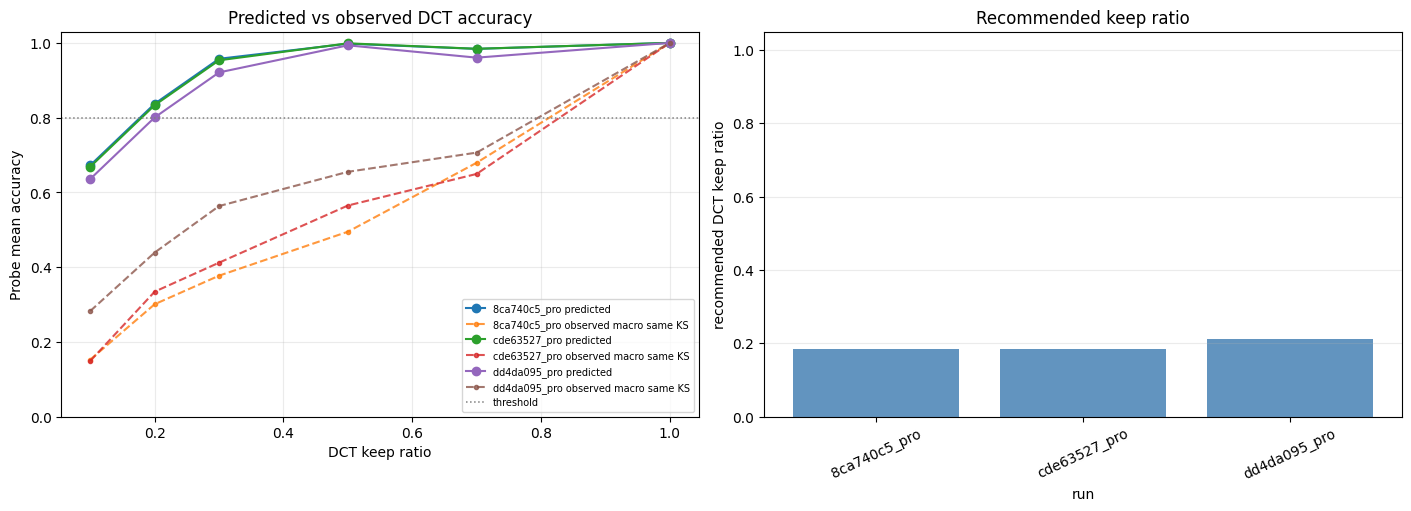

saved: G:\academic\week9_predictor_recommender_outputs\week9_predictor_recommender_summary.png


In [14]:
plot_df = week9_predicted_probe_curve.copy()
observed_plot = None
if WEEK8_OBSERVED_RUN_CSV.exists():
    observed_plot = pd.read_csv(WEEK8_OBSERVED_RUN_CSV)
    if 'source_keep_ratio' in all_ratio_result_specs.columns:
        plot_settings = all_ratio_result_specs[[
            'run_label', 'source_keep_ratio', 'ks_nearest_chans', 'ks_n_pcs'
        ]].rename(columns={'source_keep_ratio': 'ratio'})
        baseline_plot_settings = baseline_probe_specs[[
            'run_label', 'ks_nearest_chans', 'ks_n_pcs'
        ]].rename(columns={'ks_nearest_chans': 'baseline_ks_nearest_chans', 'ks_n_pcs': 'baseline_ks_n_pcs'})
        observed_plot = observed_plot.merge(plot_settings, on=['run_label', 'ratio'], how='left')
        observed_plot = observed_plot.merge(baseline_plot_settings, on='run_label', how='left')
        observed_plot['settings_match_baseline'] = (
            observed_plot['ks_nearest_chans'].eq(observed_plot['baseline_ks_nearest_chans'])
            & observed_plot['ks_n_pcs'].eq(observed_plot['baseline_ks_n_pcs'])
        )

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for run_label, grp in plot_df.groupby('run_label'):
    grp = grp.sort_values('prediction_ratio')
    axes[0].plot(grp['prediction_ratio'], grp['predicted_probe_accuracy_mean'], marker='o', label=f'{run_label[:12]} predicted')
    if observed_plot is not None:
        obs = observed_plot[observed_plot['run_label'] == run_label].sort_values('ratio')
        if 'settings_match_baseline' in obs.columns:
            obs_match = obs[obs['settings_match_baseline'].fillna(False)]
            obs_mixed = obs[~obs['settings_match_baseline'].fillna(False)]
            if not obs_match.empty:
                axes[0].plot(obs_match['ratio'], obs_match['binned_count_accuracy_macro'], linestyle='--', marker='.', alpha=0.8, label=f'{run_label[:12]} observed macro same KS')
            if not obs_mixed.empty:
                axes[0].scatter(obs_mixed['ratio'], obs_mixed['binned_count_accuracy_macro'], marker='x', alpha=0.75, label=f'{run_label[:12]} observed macro mixed KS')
        else:
            axes[0].plot(obs['ratio'], obs['binned_count_accuracy_macro'], linestyle='--', marker='.', alpha=0.7, label=f'{run_label[:12]} observed macro')
axes[0].axhline(RECOMMENDER_MIN_ACCURACY_THRESHOLD, color='gray', linestyle=':', linewidth=1.1, label='threshold')
axes[0].set_title('Predicted vs observed DCT accuracy')
axes[0].set_xlabel('DCT keep ratio')
axes[0].set_ylabel('Probe mean accuracy')
axes[0].set_ylim(0, 1.03)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=7)

rec = week9_recommendation_table.sort_values('run_label')
axes[1].bar(rec['run_label'].str[:12], rec['recommended_keep_ratio'], color='steelblue', alpha=0.85)
axes[1].set_title('Recommended keep ratio')
axes[1].set_xlabel('run')
axes[1].set_ylabel('recommended DCT keep ratio')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis='y', alpha=0.25)

fig.savefig(OUT_DIR / 'week9_predictor_recommender_summary.png', dpi=180)
plt.show()

print('saved:', OUT_DIR / 'week9_predictor_recommender_summary.png')

## Outputs

Key files written by this notebook:

- `week9_all_ratio_kilosort_result_specs.csv`: standardized callable Kilosort result specs for all discovered Week 8 DCT ratios.
- `week9_baseline_probe_specs.csv`: one `ratio=1.00` baseline spec per run; these are the inputs used by the recommender.
- `week9_baseline_neuron_features.csv`: predictor feature table extracted from each baseline probe.
- `week9_predicted_probe_accuracy_by_ratio.csv`: predictor output at configured ratios.
- `week9_predicted_neuron_accuracy_by_ratio.csv`: per-neuron predictor output at configured ratios.
- `week9_ratio_recommendations.csv`: recommender output per baseline probe.
- `week9_recommender_search_curve.csv`: sampled search curves used by the recommender.
- `week9_predictor_vs_week8_observed_by_ratio.csv`: optional prediction-vs-observed sanity check.
- `week9_recommendation_vs_week8_nearest_observed.csv`: optional nearest observed Week 8 accuracy for the recommended ratio, since recommender ratios are continuous but Week 8 was evaluated on a discrete grid.
- `week9_predictor_recommender_summary.png`: summary figure.